In [ ]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# import numpy as np

In [31]:
df = pl.read_parquet("data/donnees_finales.parquet")

### Distribution des temps par sexe sous contrainte de quantile

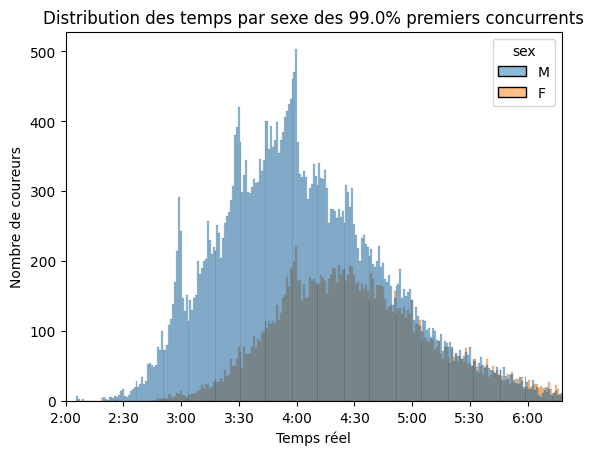

On observe que 575 coureurs ont fini en plus de 6:17:42.


In [ ]:
def distrib_tps(quantile:float):
    """Renvoie un histogramme représentant la distribution des temps avec une précision
    à la minute près répartis selon le sexe et ne considérant que la part demandée selon
    le quantile donné."""

    # Calcul de la valeur quantile et conversion en minutes
    q = df["realTime"].quantile(quantile)
    q_min = q / 60

    # Calcul du nombre de coureurs ayant fini au-delà du temps max représenté
    nb_sup_q = df.filter(pl.col("realTime") > q).shape[0]

    # Conversion en minutes
    df_plot = df.with_columns(
        (pl.col("realTime") / 60).alias("realTime_min")
    ).to_pandas()

    # Code de l'histogramme
    sns.histplot(
        data=df_plot,
        x="realTime_min",
        hue="sex",  # couleur définie par la colonne sex
        binwidth=1,  # 1 barre = 1 minute
    )


    def format_minutes(x, pos):
        """Convertit un nmobre de secondes au format H:MM."""
        h = int(x // 60)
        m = int(x % 60)
        return f"{h}:{m:02d}"

    # Formatage des axes
    ax = plt.gca()
    ax.set_xlim(120, q_min)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_minutes))

    # Légende et affichage du graphe
    plt.xlabel("Temps réel")
    plt.ylabel("Nombre de coureurs")
    plt.title(f"Distribution des temps par sexe des {quantile*100}% premiers concurrents")
    plt.show()

    # Conversion de la valeur quantile en H:MM:SS
    h = int(q) // 3600
    m = (int(q) % 3600) // 60
    s = int(q) % 60
    print(f"On observe que {nb_sup_q} coureurs ont fini en plus de {h}:{m:02d}:{s:02d}.")
    

distrib_tps(0.99)

### Répartitions des coureurs selon les seuils symboliques